In [ ]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92


In [ ]:
from ultralytics import YOLO
from roboflow import Roboflow
import matplotlib.pyplot as plt
from google.colab import files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="API_KEY_KAMU")

project = rf.workspace("bagus-hermawan").project("indonesia-rupiah-detection-z8ebn")

version = project.version(1)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Indonesia-Rupiah-Detection-1 in yolov8:: 100%|██████████| 2291/2291 [00:01<00:00, 1174.70it/s]


In [ ]:
model = YOLO("yolov8n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,
    imgsz=640
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Indonesia-Rupiah-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78b8559bb4d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [ ]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

In [ ]:
uploaded = files.upload()

nama_file = list(uploaded.keys())[0]

print("File :", nama_file)

Saving money.jpeg to money.jpeg
File : money.jpeg


In [ ]:
results = model.predict(
    source=nama_file,
    conf=0.30,
    save=True
)


image 1/1 /content/money.jpeg: 480x640 2 50000s, 46.6ms
Speed: 3.4ms preprocess, 46.6ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


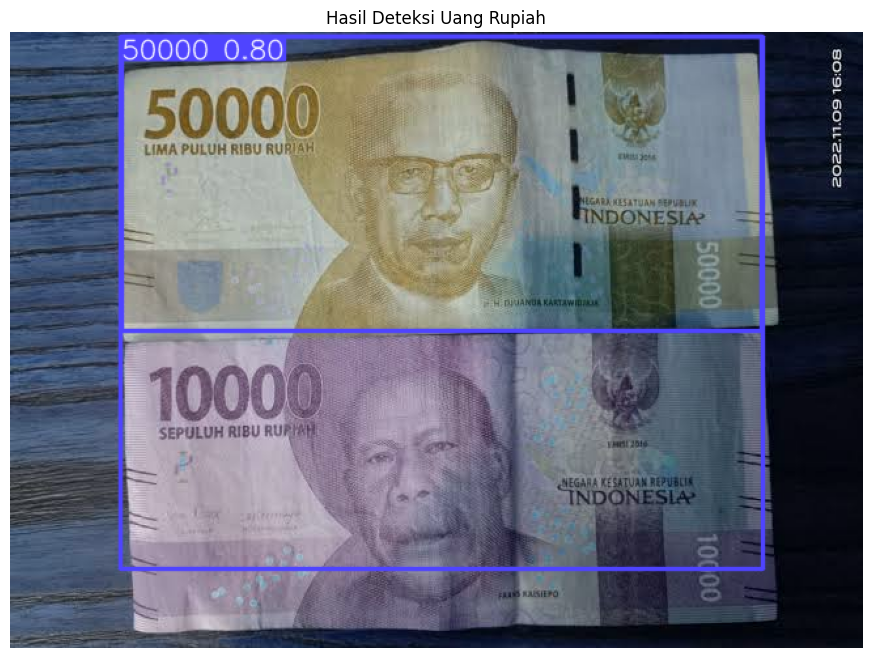

In [ ]:
import matplotlib.pyplot as plt

for r in results:
    img = r.plot()

    plt.figure(figsize=(12,8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Hasil Deteksi Uang Rupiah")
    plt.show()

In [ ]:
for r in results:

    print("="*40)
    print("HASIL DETEKSI")
    print("="*40)

    if len(r.boxes) == 0:
        print("Tidak ada uang yang terdeteksi")

    for box in r.boxes:

        kelas = int(box.cls)

        nama = model.names[kelas]

        conf = float(box.conf)

        print(f"Nominal : {nama}")
        print(f"Confidence : {conf:.2f}")
        print("-----------------------")

HASIL DETEKSI
Nominal : 50000
Confidence : 0.80
-----------------------
Nominal : 50000
Confidence : 0.47
-----------------------


In [ ]:
model.save("rupiah_model.pt")